# Design–test–learn against a *verifiable* oracle

"Optimize a design" is only meaningful if the score you optimize against is real. A model that grades
its own proposals will happily march its numbers up while the actual objective goes nowhere. mixle
0.7.0's `mixle.doe` draws an explicit **honesty boundary**: you optimize **against a
`VerifiableOracle`** — an objective from a real, non-self-graded source — and the loop **refuses to
run** without one.

This notebook builds a tiny closed-form oracle (so every number is checkable), runs the
`optimize_under_oracle` propose–test–learn loop, and shows the two guardrails that make it honest:
a self-graded oracle is rejected at construction, and there is no optimizing without an oracle at all.

## 1. A verifiable oracle carries its tier and a receipt

A `VerifiableOracle` names its **tier** — where its scores come from (`executable`, `simulation`,
`held_out_truth`, `real_measurement`) — and its `score_fn` returns an `OracleResult` with a score, a
**receipt** (evidence for the score), and a **cost**. Here the oracle is a quadratic bowl whose
optimum is a hidden target; the receipt records the true distance so we can check convergence honestly.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from mixle.doe.oracle import OracleResult, VerifiableOracle, optimize_under_oracle

target = np.array([0.5, -1.0])                 # the hidden optimum the loop must find
def score_fn(x):
    d2 = float(np.sum((np.asarray(x, float) - target) ** 2))
    return OracleResult(score=-d2, receipt={'target_dist2': d2}, cost=1.0)

oracle = VerifiableOracle(name='quadratic_bowl', tier='executable',
                          score_fn=score_fn, fidelity='exact, noiseless')
print('oracle:', oracle.name, '| tier:', oracle.tier, '| fidelity:', oracle.fidelity)

oracle: quadratic_bowl | tier: executable | fidelity: exact, noiseless


## 2. The propose–test–learn loop

`optimize_under_oracle` seeds a few initial designs, fits a surrogate, proposes candidates, tests the
best against the oracle, and repeats — a Bayesian-optimization loop, but every evaluation is a *real*
oracle call, counted and receipted. We plot the best score found so far against the number of oracle
calls.

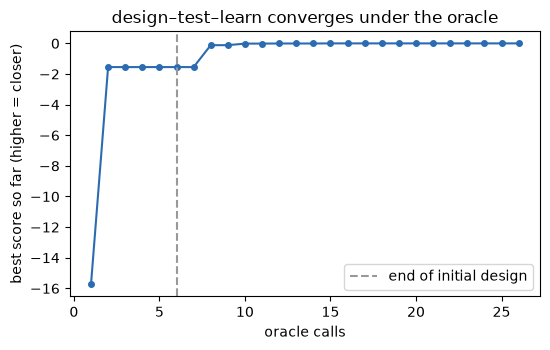

oracle calls        : 26
best design found   : [ 0.476 -1.03 ]   (hidden target [ 0.5 -1. ])
best true distance^2: 0.0015


In [2]:
run = optimize_under_oracle(oracle, [(-3.0, 3.0)] * 2,
                            n_init=6, n_iter=20, seed=0, n_candidates=256, fit_kwargs={'max_its': 60})

scores = [h.result.score for h in run.history]
best_so_far = np.maximum.accumulate(scores)

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(range(1, len(scores) + 1), best_so_far, '-o', ms=4, color='#2b6cb0')
ax.axvline(6, ls='--', c='0.6', label='end of initial design')
ax.set(xlabel='oracle calls', ylabel='best score so far (higher = closer)',
       title='design–test–learn converges under the oracle'); ax.legend()
plt.tight_layout(); plt.show()

print('oracle calls        :', run.oracle_calls)
print('best design found   :', np.round(run.best.x, 3), '  (hidden target %s)' % target)
print('best true distance^2:', round(run.best.result.receipt['target_dist2'], 4))

The loop finds the hidden optimum to within a small distance in ~20 evaluations — and every step is
accounted for. `run.report()` is the audit trail: which oracle, at what tier and fidelity, how many
calls, and the receipt for the winning design.

In [3]:
rep = run.report()
for k in ['oracle', 'tier', 'fidelity', 'oracle_calls', 'total_cost', 'best_receipt']:
    print('%-14s %s' % (k, rep[k]))

oracle         quadratic_bowl
tier           executable
fidelity       exact, noiseless
oracle_calls   26
total_cost     26.0
best_receipt   {'target_dist2': 0.0014714863545989356}


## 3. The honesty boundary

Two guardrails make "optimize" mean something. First, an oracle that **grades itself** is rejected at
construction — a self-graded objective is not evidence.

In [4]:
try:
    VerifiableOracle(name='self', tier='self_graded', score_fn=lambda x: OracleResult(0.0))
    print('no error (unexpected)')
except ValueError as e:
    print('self_graded rejected at construction:')
    print('  ', e)

self_graded rejected at construction:
   VerifiableOracle tier 'self_graded' is not a recognized verifiability tier ['executable', 'held_out_truth', 'real_measurement', 'simulation']; in particular, an oracle 'self-graded by a model' is the banned reward this boundary forbids, and is rejected at construction.


Second, there is **no optimizing without an oracle at all** — the loop refuses rather than inventing a
score.

In [5]:
try:
    optimize_under_oracle(None, [(-1.0, 1.0)])
    print('no error (unexpected)')
except ValueError as e:
    print('optimizing with no oracle is refused:')
    print('  ', e)

optimizing with no oracle is refused:
   no verifiable objective; cannot optimize. optimize_under_oracle requires a VerifiableOracle -- this is a hard precondition, not a missing default.


## What 0.7.0 gives you here

`mixle.doe` makes de-novo optimization *honest*:

* you optimize against a **`VerifiableOracle`** that declares its **tier** (executable / simulation /
  held-out / real measurement) and returns a **receipt** per evaluation;
* `optimize_under_oracle` runs a real propose–test–learn loop, **counts every oracle call**, and
  returns an auditable `report()`;
* a **self-graded** oracle is rejected, and optimizing with **no oracle** is refused — so a good-looking
  optimization curve always traces back to a real objective, never a model grading its own homework.